In [0]:
# Load the saved Delta dataset
master_df = spark.read.format("delta").load("dbfs:/Volumes/workspace/default/faers/master_df")

# Quick check
print(f"Rows: {master_df.count()}, Columns: {len(master_df.columns)}")
master_df.show(5, truncate=False)


Rows: 54861, Columns: 7
+--------+------------+---------+------------+---------------------+---+--------+
|caseid  |drugname    |dose_freq|prod_ai     |pt                   |sex|outc_cod|
+--------+------------+---------+------------+---------------------+---+--------+
|16539620|TOPIRAMATE  |QD       |TOPIRAMATE  |Infection            |F  |OT      |
|17953401|PREGABALIN  |BID      |PREGABALIN  |Wheezing             |F  |OT      |
|19165536|BACLOFEN    |Q8H      |BACLOFEN    |Dizziness            |M  |OT      |
|16214741|CYCLOSPORINE|BID      |CYCLOSPORINE|Product storage error|F  |OT      |
|17688373|NAPROXEN    |BID      |NAPROXEN    |Nausea               |F  |OT      |
+--------+------------+---------+------------+---------------------+---+--------+
only showing top 5 rows


In [0]:
%pip install git+https://github.com/rasbt/mlxtend.git

  Cloning https://github.com/rasbt/mlxtend.git to /tmp/pip-req-build-x_2_o2gx
  Running command git clone --filter=blob:none --quiet https://github.com/rasbt/mlxtend.git /tmp/pip-req-build-x_2_o2gx
  Resolved https://github.com/rasbt/mlxtend.git to commit 366f717b87f2fcaeeb67b70432b6e1a801519eff
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 14

In [0]:
# Imports
import pandas as pd
from pyspark.sql import functions as F
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth
from itertools import combinations

# -----------------------------
# Step 1 — Aggregate cases
# -----------------------------
case_level = master_df.groupBy("caseid").agg(
    F.collect_set("drugname").alias("drugs"),
    F.collect_set("pt").alias("pts")
)
# Keep only cases with >=2 drugs
case_level = case_level.filter(F.size("drugs") >= 2)
case_pd = case_level.toPandas()

# -----------------------------
# Step 2 — Reference lists
# -----------------------------
pt_values = set(master_df.select("pt").distinct().toPandas()["pt"])
drug_values = set(master_df.select("drugname").distinct().toPandas()["drugname"])

# -----------------------------
# Step 3 — Build clean transactions
# -----------------------------
transactions = []
for _, row in case_pd.iterrows():
    drugs = [d for d in row["drugs"] if d in drug_values]
    pts = [p for p in row["pts"] if p in pt_values]
    if len(drugs) >= 2 and len(pts) >= 1:
        transactions.append(drugs + pts)

print("Total transactions:", len(transactions))

# -----------------------------
# Step 4 — Encode transactions
# -----------------------------
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

# -----------------------------
# Step 5 — Run FP-Growth
# -----------------------------
frequent_itemsets = fpgrowth(
    df_encoded,
    min_support=5/len(transactions),  # only keep combos appearing at least 2 times
    use_colnames=True
)

# Keep only 3-itemsets (2 drugs + 1 PT)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
frequent_itemsets = frequent_itemsets[frequent_itemsets["length"] == 3]

# -----------------------------
# Step 6 — Manually split 2 drugs -> 1 PT
# -----------------------------
def split_two_drug_one_pt(itemset):
    drugs = [x for x in itemset if x in drug_values]
    pts = [x for x in itemset if x in pt_values]
    if len(drugs) == 2 and len(pts) == 1:
        return frozenset(drugs), frozenset(pts)
    return None, None

frequent_itemsets["antecedents"], frequent_itemsets["consequents"] = zip(
    *frequent_itemsets["itemsets"].apply(split_two_drug_one_pt)
)

# Remove invalid rows
final_rules = frequent_itemsets.dropna(subset=["antecedents","consequents"])

# -----------------------------
# Step 7 — Compute confidence and lift manually
# -----------------------------
# Build support lookup for individual drug pairs (AB)
pair_support = {}
for trans in transactions:
    drugs_in_trans = [d for d in trans if d in drug_values]
    for pair in combinations(drugs_in_trans, 2):
        pair = frozenset(pair)
        pair_support[pair] = pair_support.get(pair, 0) + 1

# Number of transactions
n_trans = len(transactions)

supports = []
confidences = []
lifts = []

for _, row in final_rules.iterrows():
    ant = row["antecedents"]
    con = list(row["consequents"])[0]
    
    sup_ABC = row["support"]
    sup_AB = pair_support[ant] / n_trans
    sup_C = sum([1 for t in transactions if con in t]) / n_trans
    
    conf = sup_ABC / sup_AB
    lift = conf / sup_C
    
    supports.append(sup_ABC)
    confidences.append(conf)
    lifts.append(lift)

final_rules["support"] = supports
final_rules["confidence"] = confidences
final_rules["lift"] = lifts

# -----------------------------
# Step 8 — Sort and show top rules
# -----------------------------
final_rules = final_rules.sort_values(by=["lift","confidence"], ascending=False)
final_rules[["antecedents","consequents","support","confidence","lift"]].head(20)


Total transactions: 5964


/home/spark-25cdfb25-969b-4463-8018-6f/.ipykernel/2708/command-8779899819009874-3124130933:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_rules["support"] = supports
/home/spark-25cdfb25-969b-4463-8018-6f/.ipykernel/2708/command-8779899819009874-3124130933:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_rules["confidence"] = confidences
/home/spark-25cdfb25-969b-4463-8018-6f/.ipykernel/2708/command-8779899819009874-3124130933:109: SettingWithCopyWarning: 
A value is trying to be set on a 

,antecedents,consequents,support,confidence,lift
1797,"(VANCOMYCIN, RITUXIMAB)",(Quadriparesis),0.001006,1.000000,852.000000
1767,"(PREDNISOLONE, MELATONIN)",(Epistaxis),0.000838,0.500000,596.400000
981,"(METOCLOPRAMIDE, CYCLOSPORINE)",(Cardiac failure),0.001509,1.000000,542.181818
1549,"(ACYCLOVIR, IBUPROFEN)",(Hepatitis acute),0.000838,0.714286,532.500000
1800,"(METOCLOPRAMIDE, PREDNISOLONE)",(Thrombotic microangiopathy),0.001677,1.000000,497.000000
1761,"(RIZATRIPTAN, ZOPICLONE)",(Dysphonia),0.000838,0.384615,458.769231
1847,"(MYCOPHENOLATE MOFETIL, LEVETIRACETAM)",(Venoocclusive liver disease),0.000838,0.312500,372.750000
1725,"(CEFTRIAXONE, LEVETIRACETAM)",(Purpura),0.001509,0.500000,331.333333
1289,"(ACYCLOVIR, AMPHOTERICIN B)",(Renal tubular disorder),0.001677,0.526316,313.894737
742,"(DIAZEPAM, METHYLPHENIDATE)",(Pulmonary embolism),0.001006,0.666667,165.666667


In [0]:
print("Total 2-drug → 1 PT rules:", len(final_rules))


Total 2-drug → 1 PT rules: 258


In [0]:
print("Unique drug pairs:", final_rules["antecedents"].nunique())
print("Unique PTs:", final_rules["consequents"].nunique())


Unique drug pairs: 114
Unique PTs: 101


In [0]:
# Imports
import pandas as pd
from pyspark.sql import functions as F
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
from itertools import combinations

# -----------------------------
# Step 1 — Aggregate cases
# -----------------------------
case_level = master_df.groupBy("caseid").agg(
    F.collect_set("drugname").alias("drugs"),
    F.collect_set("pt").alias("pts")
)
# Keep only cases with >=2 drugs
case_level = case_level.filter(F.size("drugs") >= 2)
case_pd = case_level.toPandas()

# -----------------------------
# Step 2 — Reference lists
# -----------------------------
pt_values = set(master_df.select("pt").distinct().toPandas()["pt"])
drug_values = set(master_df.select("drugname").distinct().toPandas()["drugname"])

# -----------------------------
# Step 3 — Build clean transactions
# -----------------------------
transactions = []
for _, row in case_pd.iterrows():
    drugs = [d for d in row["drugs"] if d in drug_values]
    pts = [p for p in row["pts"] if p in pt_values]
    if len(drugs) >= 2 and len(pts) >= 1:
        transactions.append(drugs + pts)

print("Total transactions:", len(transactions))

# -----------------------------
# Step 4 — Encode transactions
# -----------------------------
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

# -----------------------------
# Step 5 — FP-Growth (keep ALL frequent itemsets)
frequent_itemsets = fpgrowth(
    df_encoded,
    min_support=2/len(transactions),  # or your chosen threshold
    use_colnames=True
)

# Step 6 — Generate association rules automatically
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.1
)

# -----------------------------
# Step 7 — Compute confidence and lift manually
# -----------------------------
# Build support lookup for individual drug pairs (AB)
pair_support = {}
for trans in transactions:
    drugs_in_trans = [d for d in trans if d in drug_values]
    for pair in combinations(drugs_in_trans, 2):
        pair = frozenset(pair)
        pair_support[pair] = pair_support.get(pair, 0) + 1

# Number of transactions
n_trans = len(transactions)

supports = []
confidences = []
lifts = []
counts = []

final_rules = rules[
    (rules["antecedents"].apply(lambda x: len(x) == 2)) &
    (rules["antecedents"].apply(lambda x: all(item in drug_values for item in x))) &
    (rules["consequents"].apply(lambda x: len(x) == 1)) &
    (rules["consequents"].apply(lambda x: next(iter(x)) in pt_values))
]

for _, row in final_rules.iterrows():
    ant = row["antecedents"]
    con = list(row["consequents"])[0]
    
    sup_ABC = row["support"]
    sup_AB = pair_support[ant] / n_trans
    sup_C = sum([1 for t in transactions if con in t]) / n_trans
    
    conf = sup_ABC / sup_AB if sup_AB > 0 else 0
    lift = conf / sup_C if sup_C > 0 else 0
    
    supports.append(sup_ABC)
    confidences.append(conf)
    lifts.append(lift)
    counts.append(int(sup_ABC * n_trans))  # absolute case count

final_rules["support"] = supports
final_rules["confidence"] = confidences
final_rules["lift"] = lifts
final_rules["case_count"] = counts

# -----------------------------
# Step 9 — Sort and show top rules
# -----------------------------

final_rules = final_rules.sort_values(by=["lift","confidence"], ascending=False)
final_rules[["antecedents","consequents","case_count","support","confidence","lift"]].head(20)


Total transactions: 5964


/home/spark-25cdfb25-969b-4463-8018-6f/.ipykernel/2708/command-5414327513508125-3149371301:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_rules["support"] = supports
/home/spark-25cdfb25-969b-4463-8018-6f/.ipykernel/2708/command-5414327513508125-3149371301:102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_rules["confidence"] = confidences
/home/spark-25cdfb25-969b-4463-8018-6f/.ipykernel/2708/command-5414327513508125-3149371301:103: SettingWithCopyWarning: 
A value is trying to be set on a 

,antecedents,consequents,case_count,support,confidence,lift
20246,"(ACYCLOVIR, ZOLPIDEM)",(Blood HIV RNA increased),2,0.000335,1.000000,2982.000000
18104,"(DOMPERIDONE, CYCLOSPORINE)",(Cytopenia),2,0.000335,1.000000,1988.000000
18022,"(ZOLPIDEM, RISPERIDONE)",(Hyperammonaemic encephalopathy),2,0.000335,1.000000,1491.000000
20289,"(ZOPICLONE, DONEPEZIL)",(Multiple drug therapy),2,0.000335,1.000000,1491.000000
17322,"(LAMOTRIGINE, BACLOFEN)",(Immune thrombocytopenia),3,0.000503,0.750000,1491.000000
12292,"(CANDESARTAN, ZOLPIDEM)",(Odynophagia),2,0.000335,0.500000,1491.000000
22385,"(VANCOMYCIN, LEVETIRACETAM)",(Linear IgA disease),4,0.000671,1.000000,1192.800000
17691,"(ZOLPIDEM, TIZANIDINE)",(Pancreatitis necrotising),3,0.000503,0.750000,894.600000
15563,"(AMITRIPTYLINE, MODAFINIL)",(Urticaria),2,0.000335,1.000000,852.000000
20721,"(VANCOMYCIN, RITUXIMAB)",(Quadriparesis),6,0.001006,1.000000,852.000000


In [0]:
# -----------------------------
# Step 10 — Convert frozensets to normal columns for CSV
# -----------------------------

# Split antecedents (frozenset of 2 drugs) into Drug1 and Drug2
final_rules["Drug1"] = final_rules["antecedents"].apply(lambda x: list(x)[0] if len(x) > 0 else "")
final_rules["Drug2"] = final_rules["antecedents"].apply(lambda x: list(x)[1] if len(x) > 1 else "")

# Convert consequents (frozenset of 1 PT) to string
final_rules["PT"] = final_rules["consequents"].apply(lambda x: list(x)[0] if len(x) > 0 else "")

# Optional: drop original frozenset columns
final_rules_clean = final_rules.drop(columns=["antecedents", "consequents"])

# Reorder columns for clarity
final_rules_clean = final_rules_clean[
    ["Drug1", "Drug2", "PT", "case_count", "support", "confidence", "lift"]
]

# Save to CSV
final_rules_clean.to_csv("drug_pairs_rules.csv", index=False)


In [0]:
# Sort rules by case count (descending)
final_rules_sorted = final_rules.sort_values(by="case_count", ascending=False)

# Show the top 20 rules with highest case counts

final_rules_sorted[
        ["antecedents", "consequents", "case_count", "support", "confidence", "lift"]
    ].head(20)



,antecedents,consequents,case_count,support,confidence,lift
1570,"(LACOSAMIDE, LEVETIRACETAM)",(Drug ineffective),52,0.008719,0.179931,2.592047
1877,"(VALPROIC ACID, LEVETIRACETAM)",(Drug ineffective),27,0.004527,0.194245,2.798248
1485,"(CLOBAZAM, LEVETIRACETAM)",(Drug ineffective),26,0.004359,0.152941,2.203240
1486,"(LACOSAMIDE, CLOBAZAM)",(Drug ineffective),21,0.003521,0.238636,3.437747
3383,"(PREDNISOLONE, AZATHIOPRINE)",(Therapy non-responder),20,0.003353,0.108696,8.643478
1576,"(PREDNISOLONE, CYCLOSPORINE)",(Drug ineffective),20,0.003353,0.119760,1.725245
1879,"(VALPROIC ACID, LACOSAMIDE)",(Drug ineffective),18,0.003018,0.225000,3.241304
1081,"(PHENYTOIN, GABAPENTIN)",(Drug ineffective),17,0.002850,0.377778,5.442190
1971,"(IBUPROFEN, GABAPENTIN)",(Drug ineffective),17,0.002850,0.274194,3.949977
1073,"(PHENYTOIN, LEVETIRACETAM)",(Drug ineffective),17,0.002850,0.200000,2.881159


In [0]:
final_rules["antecedents_str"] = final_rules["antecedents"].apply(lambda x: ", ".join(list(x)))
final_rules["consequents_str"] = final_rules["consequents"].apply(lambda x: ", ".join(list(x)))


# Save all rules into a CSV file
final_rules_sorted[
    ["antecedents", "consequents", "case_count", "support", "confidence", "lift"]
].to_csv("alll_rules.csv", index=False)

print("All rules saved to all_rules.csv")


All rules saved to all_rules.csv


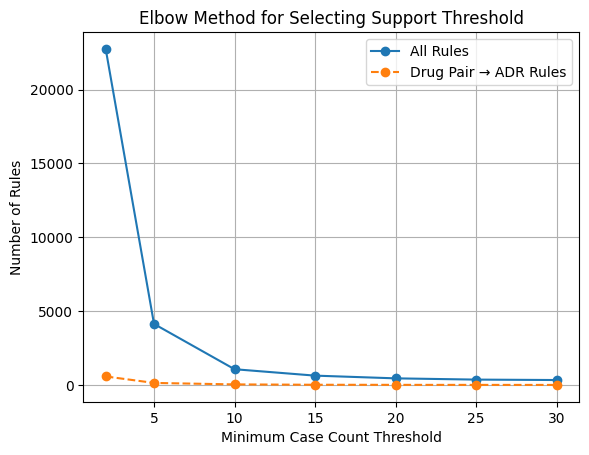

In [0]:


from mlxtend.frequent_patterns import fpgrowth, association_rules

# Total transactions
n_trans = len(transactions)

# Thresholds in terms of case counts
threshold_cases = [2, 5, 10, 15, 20, 25, 30]

rule_counts = []
filtered_rule_counts = []

for t in threshold_cases:
    min_support = t / n_trans
    
    # FP-Growth
    fi = fpgrowth(
        df_encoded,
        min_support=min_support,
        use_colnames=True
    )
    
    # Association rules
    rules = association_rules(
        fi,
        metric="confidence",
        min_threshold=0.1
    )
    
    # Count ALL rules
    rule_counts.append(len(rules))
    
    # Apply your filter: 2 drugs → 1 PT
    filtered_rules = rules[
        (rules["antecedents"].apply(lambda x: len(x) == 2)) &
        (rules["antecedents"].apply(lambda x: all(item in drug_values for item in x))) &
        (rules["consequents"].apply(lambda x: len(x) == 1)) &
        (rules["consequents"].apply(lambda x: next(iter(x)) in pt_values))
    ]
    
    filtered_rule_counts.append(len(filtered_rules))

# -----------------------------
# Plot elbow curve
# -----------------------------
plt.figure()
plt.plot(threshold_cases, rule_counts, marker='o', label="All Rules")
plt.plot(threshold_cases, filtered_rule_counts, marker='o', linestyle='--', label="Drug Pair → ADR Rules")

plt.xlabel("Minimum Case Count Threshold")
plt.ylabel("Number of Rules")
plt.title("Elbow Method for Selecting Support Threshold")
plt.legend()
plt.grid()

plt.show()

In [0]:
len(final_rules)

136

In [0]:
# Imports
import pandas as pd
from pyspark.sql import functions as F
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
from itertools import combinations

# -----------------------------
# Step 1 — Aggregate cases
# -----------------------------
case_level = master_df.groupBy("caseid").agg(
    F.collect_set("drugname").alias("drugs"),
    F.collect_set("pt").alias("pts")
)
# Keep only cases with >=2 drugs
case_level = case_level.filter(F.size("drugs") >= 2)
case_pd = case_level.toPandas()

# -----------------------------
# Step 2 — Reference lists
# -----------------------------
pt_values = set(master_df.select("pt").distinct().toPandas()["pt"])
drug_values = set(master_df.select("drugname").distinct().toPandas()["drugname"])

# -----------------------------
# Step 3 — Build clean transactions
# -----------------------------
transactions = []
for _, row in case_pd.iterrows():
    drugs = [d for d in row["drugs"] if d in drug_values]
    pts = [p for p in row["pts"] if p in pt_values]
    if len(drugs) >= 2 and len(pts) >= 1:
        transactions.append(drugs + pts)

print("Total transactions:", len(transactions))

# -----------------------------
# Step 4 — Encode transactions
# -----------------------------
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

# -----------------------------
# Step 5 — FP-Growth
# -----------------------------
# Use a more meaningful support threshold: at least 10 cases
min_support = 5 / len(transactions)

frequent_itemsets = fpgrowth(
    df_encoded,
    min_support=min_support,
    use_colnames=True
)

# Step 6 — Association rules
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.1
)

# -----------------------------
# Step 7 — Filter drug-pair → PT rules
# -----------------------------
final_rules = rules[
    (rules["antecedents"].apply(lambda x: len(x) == 2)) &
    (rules["antecedents"].apply(lambda x: all(item in drug_values for item in x))) &
    (rules["consequents"].apply(lambda x: len(x) == 1)) &
    (rules["consequents"].apply(lambda x: next(iter(x)) in pt_values))
].copy()

# -----------------------------
# Step 8 — Add absolute counts
# -----------------------------
n_trans = len(transactions)

# Support counts for antecedent pairs
pair_support = {}
for trans in transactions:
    drugs_in_trans = [d for d in trans if d in drug_values]
    for pair in combinations(drugs_in_trans, 2):
        pair = frozenset(pair)
        pair_support[pair] = pair_support.get(pair, 0) + 1

supports = []
confidences = []
lifts = []
counts = []

for _, row in final_rules.iterrows():
    ant = row["antecedents"]
    con = list(row["consequents"])[0]
    
    sup_ABC = row["support"]  # fraction
    sup_AB = pair_support[ant] / n_trans
    sup_C = sum([1 for t in transactions if con in t]) / n_trans
    
    conf = sup_ABC / sup_AB if sup_AB > 0 else 0
    lift = conf / sup_C if sup_C > 0 else 0
    
    supports.append(sup_ABC)
    confidences.append(conf)
    lifts.append(lift)
    counts.append(int(sup_ABC * n_trans))  # absolute case count

final_rules["support"] = supports
final_rules["confidence"] = confidences
final_rules["lift"] = lifts
final_rules["case_count"] = counts
counts.append(int(sup_ABC * n_trans))  # absolute case count


# -----------------------------
# Step 9 — Sort and show top rules
# -----------------------------

final_rules = final_rules.sort_values(by=["lift","confidence"], ascending=False)
final_rules[["antecedents","consequents","case_count","support","confidence","lift"]].head(20)



Total transactions: 5964


,antecedents,consequents,case_count,support,confidence,lift
4033,"(VANCOMYCIN, RITUXIMAB)",(Quadriparesis),6,0.001006,1.000000,852.000000
3986,"(PREDNISOLONE, MELATONIN)",(Epistaxis),5,0.000838,0.500000,596.400000
2132,"(METOCLOPRAMIDE, CYCLOSPORINE)",(Cardiac failure),9,0.001509,1.000000,542.181818
3501,"(ACYCLOVIR, IBUPROFEN)",(Hepatitis acute),5,0.000838,0.714286,532.500000
4038,"(METOCLOPRAMIDE, PREDNISOLONE)",(Thrombotic microangiopathy),10,0.001677,1.000000,497.000000
3975,"(ZOPICLONE, RIZATRIPTAN)",(Dysphonia),5,0.000838,0.384615,458.769231
4128,"(MYCOPHENOLATE MOFETIL, LEVETIRACETAM)",(Venoocclusive liver disease),5,0.000838,0.312500,372.750000
3893,"(LEVETIRACETAM, CEFTRIAXONE)",(Purpura),9,0.001509,0.500000,331.333333
3077,"(ACYCLOVIR, AMPHOTERICIN B)",(Renal tubular disorder),10,0.001677,0.526316,313.894737
1552,"(DIAZEPAM, METHYLPHENIDATE)",(Pulmonary embolism),6,0.001006,0.666667,165.666667


In [0]:
len(final_rules)

258

In [0]:
import pandas as pd

# Replace 'final_rules' with your DataFrame variable name
final_rules.to_csv('final_rules.csv', index=False)
print("Final rules saved to 'final_rules.csv'")

Final rules saved to 'final_rules.csv'


In [0]:
# -----------------------------
# Imports
# -----------------------------
import pandas as pd
from pyspark.sql import functions as F
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth
from itertools import combinations

# -----------------------------
# Step 1 — Aggregate cases
# -----------------------------
case_level = master_df.groupBy("caseid").agg(
    F.collect_set("drugname").alias("drugs"),
    F.collect_set("pt").alias("pts")
)

case_level = case_level.filter(F.size("drugs") >= 2)
case_pd = case_level.toPandas()

# -----------------------------
# Step 2 — Reference lists
# -----------------------------
master_pd = master_df.toPandas()

pt_values = set(master_pd["pt"].unique())
drug_values = set(master_pd["drugname"].unique())

# -----------------------------
# Step 3 — Build transactions
# -----------------------------
transactions = []
for _, row in case_pd.iterrows():
    drugs = [d for d in row["drugs"] if d in drug_values]
    pts = [p for p in row["pts"] if p in pt_values]
    
    if len(drugs) >= 2 and len(pts) >= 1:
        transactions.append(drugs + pts)

print("Total transactions:", len(transactions))

# -----------------------------
# Step 4 — Encode
# -----------------------------
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

# -----------------------------
# Step 5 — FP-Growth
# -----------------------------
frequent_itemsets = fpgrowth(
    df_encoded,
    min_support=5/len(transactions),
    use_colnames=True
)

# Keep only 3-itemsets
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
frequent_itemsets = frequent_itemsets[frequent_itemsets["length"] == 3]

# -----------------------------
# Step 6 — Split rules (2 drugs → 1 PT)
# -----------------------------
def split_two_drug_one_pt(itemset):
    drugs = [x for x in itemset if x in drug_values]
    pts = [x for x in itemset if x in pt_values]
    if len(drugs) == 2 and len(pts) == 1:
        return frozenset(drugs), frozenset(pts)
    return None, None

frequent_itemsets["antecedents"], frequent_itemsets["consequents"] = zip(
    *frequent_itemsets["itemsets"].apply(split_two_drug_one_pt)
)

final_rules = frequent_itemsets.dropna(subset=["antecedents", "consequents"])

# -----------------------------
# Step 7 — Compute metrics
# -----------------------------
pair_support = {}
for trans in transactions:
    drugs_in_trans = [d for d in trans if d in drug_values]
    for pair in combinations(drugs_in_trans, 2):
        pair = frozenset(pair)
        pair_support[pair] = pair_support.get(pair, 0) + 1

n_trans = len(transactions)

supports, confidences, lifts, case_counts = [], [], [], []

for _, row in final_rules.iterrows():
    ant = row["antecedents"]
    con = list(row["consequents"])[0]

    sup_ABC = row["support"]
    sup_AB = pair_support[ant] / n_trans
    sup_C = sum([1 for t in transactions if con in t]) / n_trans

    conf = sup_ABC / sup_AB if sup_AB > 0 else 0
    lift = conf / sup_C if sup_C > 0 else 0

    supports.append(sup_ABC)
    confidences.append(conf)
    lifts.append(lift)
    case_counts.append(int(sup_ABC * n_trans))

final_rules["support"] = supports
final_rules["confidence"] = confidences
final_rules["lift"] = lifts
final_rules["case_count"] = case_counts

# -----------------------------
# Step 8 — Outcome processing
# -----------------------------

# Map outcome codes → labels
outcome_map = {
    "DE": "Critical",
    "LT": "Critical",
    "HO": "Serious",
    "DS": "Serious",
    "CA": "Serious",
    "RI": "Moderate",
    "OT": "Moderate"
}

master_pd["outcome_label"] = master_pd["outc_cod"].map(outcome_map).fillna("Unknown")

# Severity ranking
severity_order = {
    "Critical": 1,
    "Serious": 2,
    "Moderate": 3,
    "Unknown": 4
}

# Count outcomes per PT
pt_counts = master_pd.groupby(["pt", "outcome_label"]).size().reset_index(name="count")

# Function to pick final outcome
def pick_outcome(df):
    max_count = df["count"].max()
    candidates = df[df["count"] == max_count]

    if len(candidates) == 1:
        return candidates["outcome_label"].values[0]
    else:
        candidates = candidates.copy()
        candidates["severity"] = candidates["outcome_label"].map(severity_order)
        return candidates.sort_values("severity", ascending=False)["outcome_label"].values[0]

pt_outcome_final = pt_counts.groupby("pt").apply(pick_outcome).reset_index(name="final_outcome")

# -----------------------------
# Step 9 — Merge outcome
# -----------------------------
final_rules["pt"] = final_rules["consequents"].apply(lambda x: list(x)[0])

final_rules = final_rules.merge(pt_outcome_final, how="left", on="pt")

# -----------------------------
# Step 10 — Final sorting
# -----------------------------
final_rules = final_rules.sort_values(by=["lift", "confidence"], ascending=False)

# -----------------------------
# -----------------------------
# Step 11 — Prepare final result
# -----------------------------
result = final_rules.copy()

# Convert antecedents and consequents sets to readable strings
result["drug_1"] = result["antecedents"].apply(lambda x: list(x)[0])
result["drug_2"] = result["antecedents"].apply(lambda x: list(x)[1])
result["pt"] = result["consequents"].apply(lambda x: list(x)[0])

# Keep only necessary columns
result = result[[
    "drug_1",
    "drug_2",
    "pt",
    "final_outcome",
    "case_count",
    "support",
    "confidence",
    "lift"
]]

# Round numeric values for clarity
result["support"] = result["support"].round(4)
result["confidence"] = result["confidence"].round(2)
result["lift"] = result["lift"].round(2)

# -----------------------------
# Step 12 — Save to CSV in workspace directory
# -----------------------------
output_path = "/Workspace/Users/navoda.20222032@iit.ac.lk/result.csv"
result.to_csv(output_path, index=False)

print(f"CSV saved to: {output_path}")

# -----------------------------
# Optional: Display top 20
# -----------------------------
result.head(20)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/pandas/types.py:931: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return pser.astype(pandas_type, copy=False)
/databricks/python/lib/python3.12/site-packages/pyspark/sql/pandas/types.py:931: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return pser.astype(pandas_type, copy=False)


Total transactions: 5964
CSV saved to: /Workspace/Users/navoda.20222032@iit.ac.lk/result.csv


,drug_1,drug_2,pt,final_outcome,case_count,support,confidence,lift
245,VANCOMYCIN,RITUXIMAB,Quadriparesis,Serious,6,0.0010,1.00,852.00
180,PREDNISOLONE,MELATONIN,Epistaxis,Moderate,5,0.0008,0.50,596.40
218,METOCLOPRAMIDE,CYCLOSPORINE,Cardiac failure,Serious,9,0.0015,1.00,542.18
217,ACYCLOVIR,IBUPROFEN,Hepatitis acute,Moderate,5,0.0008,0.71,532.50
251,METOCLOPRAMIDE,PREDNISOLONE,Thrombotic microangiopathy,Moderate,10,0.0017,1.00,497.00
238,RIZATRIPTAN,ZOPICLONE,Dysphonia,Moderate,5,0.0008,0.38,458.77
257,MYCOPHENOLATE MOFETIL,LEVETIRACETAM,Venoocclusive liver disease,Moderate,5,0.0008,0.31,372.75
234,CEFTRIAXONE,LEVETIRACETAM,Purpura,Moderate,9,0.0015,0.50,331.33
126,ACYCLOVIR,AMPHOTERICIN B,Renal tubular disorder,Moderate,10,0.0017,0.53,313.89
225,DIAZEPAM,METHYLPHENIDATE,Pulmonary embolism,Serious,6,0.0010,0.67,165.67
